# Packages

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from eda_utils import plot_reg_and_kde_grid, plot_corr_heatmap

# ----------------------------
# Feature Store
# ----------------------------
from feast import FeatureStore

# Importation

In [2]:
# --------------------------------------------------
# Init Feast
# --------------------------------------------------
REPO_PATH = (
    Path.cwd().parent.parent
    / "2_data_processing"
    / "feature_store"
    / "feast_repo"
    / "feature_repo"
)

store = FeatureStore(repo_path=str(REPO_PATH))

# --------------------------------------------------
# Définir univers temporel
# --------------------------------------------------
dates = pd.date_range(
    start="1960-01-01",
    end="2025-09-01",
    freq="MS",
)

# --------------------------------------------------
# Series IDs (option 1 : explicite, OK pour maintenant)
# --------------------------------------------------
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

entity_df = pd.MultiIndex.from_product(
    [series_ids, dates],
    names=["series_id", "date"],
).to_frame(index=False)

# --------------------------------------------------
# Récupération Feast
# --------------------------------------------------
df_stationary = store.get_historical_features(
    entity_df=entity_df,
    features=["raw_value:value"],
).to_df()

# --------------------------------------------------
# LONG → WIDE
# --------------------------------------------------
df_wide = (
    df_stationary
    .rename(columns={"stationary_value__value": "value"})
    .pivot(index="date", columns="series_id", values="value")
    .sort_index()
)

df = df_wide.copy()

df.head()

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.


series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,39.6291,29.37,15.789,24.2078,298.2,2.97,2695.694,58.03,4.35,5.2,0.0
1960-02-01 00:00:00+00:00,39.7872,29.41,15.858,23.9924,298.4,2.97,2698.789,55.78,3.96,4.8,0.0
1960-03-01 00:00:00+00:00,40.0180,29.41,16.083,23.7770,299.3,2.97,2703.859,55.02,3.31,5.4,0.0
1960-04-01 00:00:00+00:00,40.5152,29.54,16.331,23.5885,300.1,2.97,2713.243,55.73,3.23,5.2,0.0
1960-05-01 00:00:00+00:00,40.8926,29.57,16.002,23.5616,300.9,2.97,2719.777,55.22,3.29,5.1,1.0


# Split

On ne peut pas utiliser l'ensemble des observations maintenant pour explorer les données, sinon on entraine un dataleakage. 

Il faut donc, séparer les données en TRAIN et TEST :
- TRAIN : avant décembre 1989 ; 
- TEST : après décembre 1990.

Notons bien que celà ne veut pas dire qu'on entrainera plus tard nos modèles de 1960 1989 uniquement. Nos modèles seront entrainés sur la base de Out-Of-Sample(OOS).

Celà veut dire les choses suivantes.

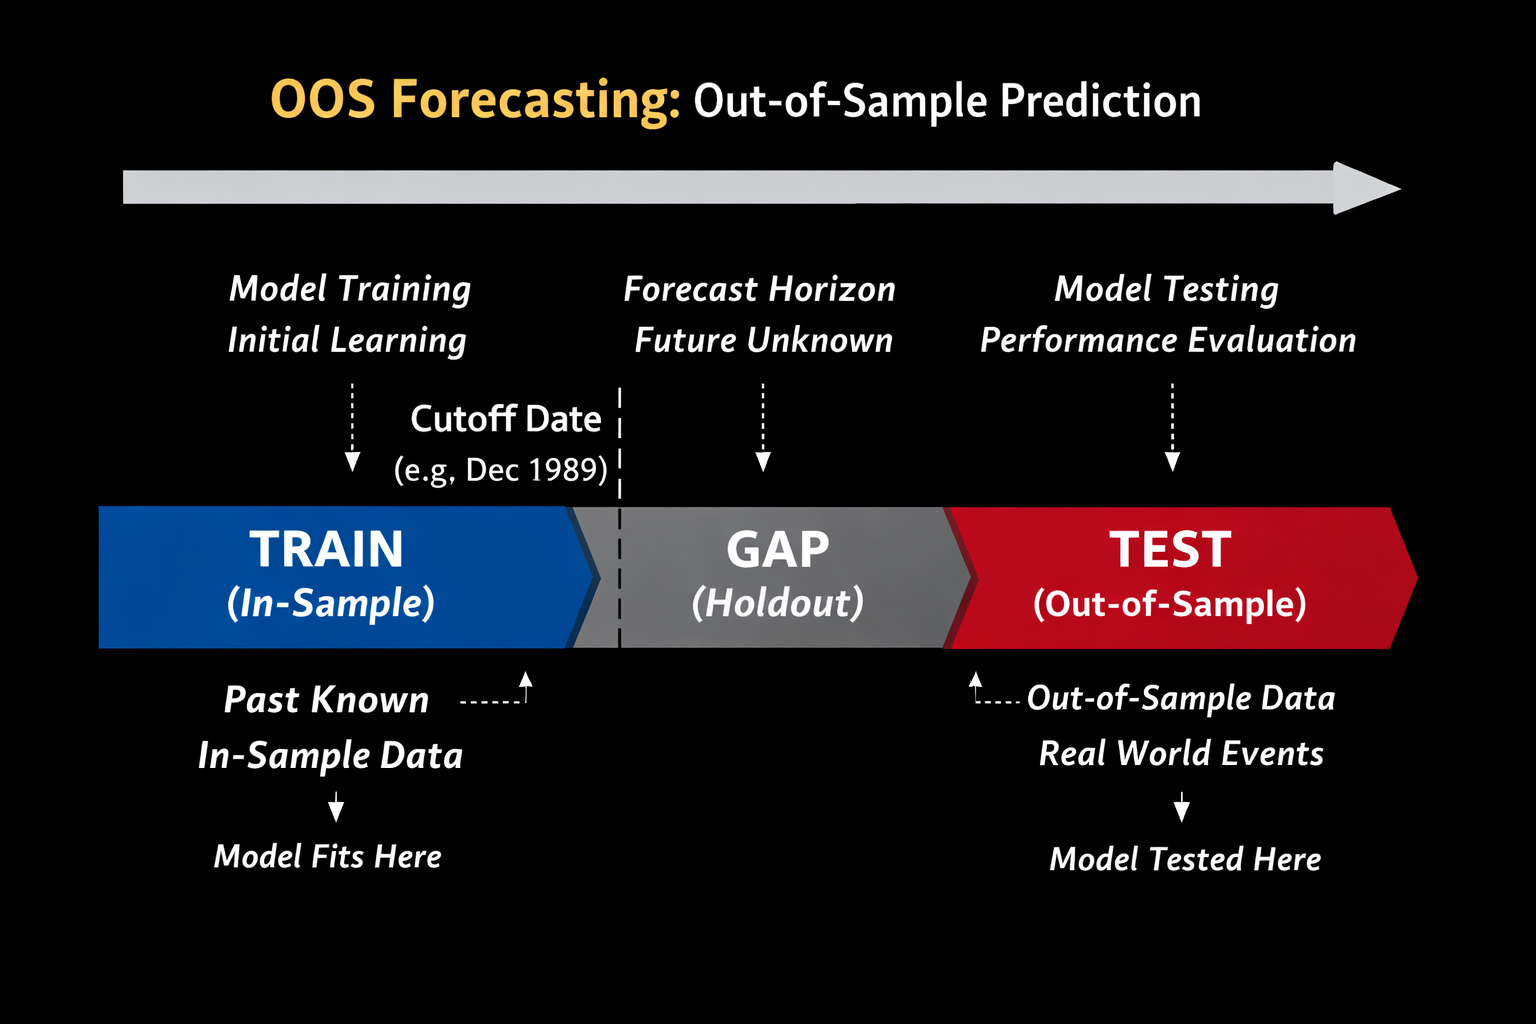

De 1960 à 2025, nos modèles s'entrainent toujours dans un laps de temps et testés dans une autre laps de temps (à préciser ultérieurement l'horizon). A partir de 1990 à 2025, par contre, on évalue en profondeur les modèles s'ils arrivent à bien gérer un environnement macroéconomique distinct, marqué par des crises financières, des politiques monétaires non conventionnelles et des chocs exogènes. 

Notre exploration ne se porte pas sur les périodes post-1990.

In [3]:
end_time_train = "1989-12" # 

df_train = df[df.index <= end_time_train]
df_test = df[df.index > end_time_train]

In [4]:
print(df_train.index[-1])
print(df_test.index[0])

1989-12-01 00:00:00+00:00
1990-01-01 00:00:00+00:00


# Avoir un dataset décalé de 12 mois

Notre Objectif est de prédire et d'expliquer l'évolution du chômage dans 12 mois. Notre exploration devrait se baser alors sur cette réalité du modèle.

In [5]:
# Colonnes à décaler sauf UNRATE
cols_to_lag = [col for col in df_train.columns if col != "UNRATE"]

# Création des lags 12 pour toutes les variables sauf UNRATE
df_train_lags = df_train[cols_to_lag].shift(12)
df_train_lags.columns = [f"{col}_lags_12" for col in cols_to_lag]

# Ajout du lag 12 de UNRATE
df_train_lags["UNRATE_lags_12"] = df_train["UNRATE"].shift(12)

# Ajout de la colonne UNRATE originale
df_train_lags["UNRATE"] = df_train["UNRATE"]

# Nettoyage
df_train_lags = df_train_lags.dropna()

In [6]:
df_train_lags.head()

,BUSLOANS_lags_12,CPIAUCSL_lags_12,DPCERA3M086SBEA_lags_12,INDPRO_lags_12,M2SL_lags_12,OILPRICEX_lags_12,RPI_lags_12,SP500_lags_12,TB3MS_lags_12,USREC_lags_12,UNRATE_lags_12,UNRATE
date,,,,,,,,,,,,
1961-01-01 00:00:00+00:00,39.6291,29.37,15.789,24.2078,298.2,2.97,2695.694,58.03,4.35,0.0,5.2,6.6
1961-02-01 00:00:00+00:00,39.7872,29.41,15.858,23.9924,298.4,2.97,2698.789,55.78,3.96,0.0,4.8,6.9
1961-03-01 00:00:00+00:00,40.0180,29.41,16.083,23.7770,299.3,2.97,2703.859,55.02,3.31,0.0,5.4,6.9
1961-04-01 00:00:00+00:00,40.5152,29.54,16.331,23.5885,300.1,2.97,2713.243,55.73,3.23,0.0,5.2,7.0
1961-05-01 00:00:00+00:00,40.8926,29.57,16.002,23.5616,300.9,2.97,2719.777,55.22,3.29,1.0,5.1,7.1


# Analyse bivariée

- Avant de développer un modèle d'IA, il faut comprendre la nature de relation entre la variable cible et à expliquer UNRATE avec les prédicateurs. Celà nous permet de penser aux modèles possiblement adaptables dans nos données. 
- L'hypothèse centrale à vérifier est que : leur relation est-t-elle linéaire?
- Quelles variables sont succeptibles d'influencer le UNRATE dans un modèle linéaire ?

## Confirmons-nous si le taux de chômage est liée à l'indicateur de récession ? 

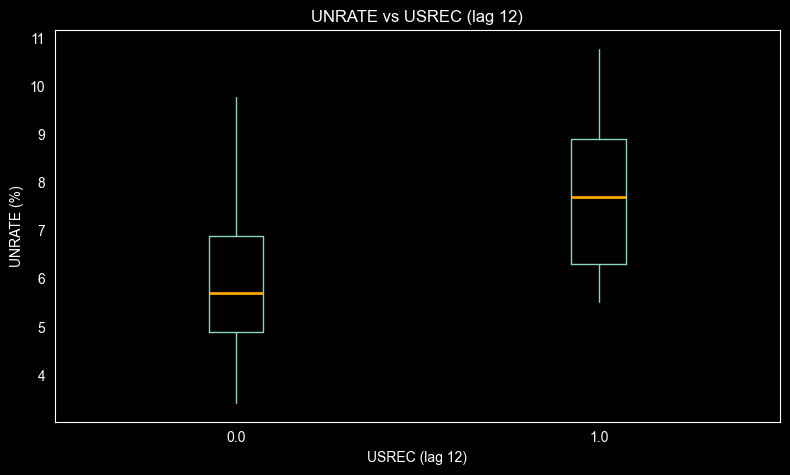

In [15]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8, 5))

df_train_lags.boxplot(
    column="UNRATE",
    by="USREC_lags_12",
    ax=ax,
    grid=False,
    medianprops=dict(color="orange", linewidth=2)
)

ax.set_title("UNRATE vs USREC (lag 12)")
ax.set_xlabel("USREC (lag 12)")
ax.set_ylabel("UNRATE (%)")
plt.suptitle("")

plt.tight_layout()
plt.show()

On constate que les taux de croissance chômage durant la période de récession sont nettement différentes que durant le temps normal. Dans la période de mauvaise performance économique, le chômage s'accroit de 1% en général. En temps normal, la tendance est à la baisse. Des valeurs extrêmes peuvent avoir lieu quand même.

Cette relation est fondamentale dans notre étude. Il faut la vérifier si elle est statistiquement significative. 

In [16]:
from scipy.stats import mannwhitneyu

# Séparation des groupes
unrate_no_recession = df_train_lags.loc[
    df_train_lags["USREC_lags_12"] == 0, "UNRATE"
].dropna()

unrate_recession = df_train_lags.loc[
    df_train_lags["USREC_lags_12"] == 1, "UNRATE"
].dropna()

# Test de Mann-Whitney
stat, p_value = mannwhitneyu(
    unrate_no_recession,
    unrate_recession,
    alternative="two-sided"  # ou "less"/"greater" selon ton hypothèse
)

print(f"U statistic = {stat:.2f}")
print(f"p-value     = {p_value:.4e}")

U statistic = 2656.50
p-value     = 7.6134e-17


**Hypothèses**
- H₀ : la distribution du taux de chômage (UNRATE) est identique lorsqu'on est dans une période de récession (USREC) ou non = 0 ou 1.
- H₁ : la distribution du UNRATE diffère selon la valeur de USREC.

**Test statistique**
- Test de Mann–Whitney U, adapté à la comparaison de deux groupes indépendants sans hypothèse de normalité.

**Valeur critique et région de rejet**
- Au seuil α = 5 % (test bilatéral), la valeur critique est |z| = 1,96.
- La région de rejet est |z| > 1,96 (ou équivalemment p-value < 0,05).

**Statistique observée**
- U = 2656,5
- p-value = 7,6 × 10⁻¹⁷

**Décision**
- La p-value étant largement inférieure au seuil de 5 %, l’hypothèse nulle est rejetée.
- Chômage et récession sont reliées. 
- Le graphique d'en haut nous confirme une relation positive. Dans la période de récision, la croissance du chômage augmente et vice-versa. C'est économiquement logique. 

## Pourrons-nous 

In [22]:
import pandas as pd
import plotly.graph_objects as go

# ----------------------------
# 1) UNRATE + USREC
# ----------------------------
df_plot = df[["UNRATE", "USREC"]].copy()

# Datetime index + make tz-naive if needed
idx = pd.to_datetime(df_plot.index)
if getattr(idx, "tz", None) is not None:
    idx = idx.tz_convert(None)
df_plot.index = idx

# ----------------------------
# 2) Detect recession spans (USREC = 1)
# ----------------------------
usrec = df_plot["USREC"]

start_mask = (usrec == 1) & (usrec.shift(1).fillna(0) == 0)
end_mask   = (usrec == 1) & (usrec.shift(-1).fillna(0) == 0)

recessions = pd.DataFrame({
    "start": usrec.index[start_mask],
    "end":   usrec.index[end_mask],
}).reset_index(drop=True)

# Ensure tz-naive
recessions["start"] = pd.to_datetime(recessions["start"])
recessions["end"]   = pd.to_datetime(recessions["end"])
if getattr(recessions["start"].dt, "tz", None) is not None:
    recessions["start"] = recessions["start"].dt.tz_convert(None)
    recessions["end"]   = recessions["end"].dt.tz_convert(None)

# ----------------------------
# 3) Labels (English, NO dates in text)
#    - Crises: no word "recession"
#    - Other spans: keep "Recession" wording
# ----------------------------
labels_by_year = {
    # non-crisis recessions (keep "Recession")
    1960: "Post-Eisenhower Recession",
    1970: "1969–70 Recession",
    1990: "Gulf War Recession",

    # crises (NO "Recession")
    1973: "Oil Shock Crisis",
    1980: "Oil Shock Crisis 2",
    2001: "Dot-com Bust",
    2007: "Subprime Crisis",
    2008: "Subprime Crisis",   # robustness if your span starts in 2008
    2020: "Covid-19",
}

# ----------------------------
# 4) Plotly: line + shaded spans + labels
# ----------------------------
fig = go.Figure()

# UNRATE line
fig.add_trace(
    go.Scatter(
        x=df_plot.index,
        y=df_plot["UNRATE"],
        mode="lines",
        name="Unemployment rate (UNRATE)",
        line=dict(width=3, color="#FFA500"),
    )
)

y_max = float(df_plot["UNRATE"].max())
y_text = y_max * 0.97

shapes = []
annotations = []
used_labels = set()  # avoid duplicates (e.g., 2007 & 2008 both map to Subprime Crisis)

for _, row in recessions.iterrows():
    start, end = row["start"], row["end"]

    # Shaded area for USREC=1
    shapes.append(
        dict(
            type="rect",
            xref="x",
            yref="paper",
            x0=start,
            x1=end,
            y0=0,
            y1=1,
            fillcolor="red",
            opacity=0.25,
            line=dict(width=0),
            layer="below",
        )
    )

    # Label by year coverage (robust to month alignment)
    label = None
    for year, name in labels_by_year.items():
        if start.year <= year <= end.year and name not in used_labels:
            label = name
            break

    if label:
        used_labels.add(label)
        mid = start + (end - start) / 2
        annotations.append(
            dict(
                x=mid,
                y=y_text,
                xref="x",
                yref="y",
                text=label,
                showarrow=False,
                textangle=-90,
                font=dict(size=11, color="white"),
                opacity=0.95,
            )
        )

# ----------------------------
# 5) Layout (English)
# ----------------------------
fig.update_layout(
    title="UNRATE with NBER Recession Shading",
    xaxis_title="Year",
    yaxis_title="UNRATE (%)",
    template="plotly_dark",
    shapes=shapes,
    annotations=annotations,
    height=420,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        title_text="",
    ),
)

fig.show()

In [20]:
import pandas as pd
import plotly.graph_objects as go

# ----------------------------
# 1) Données (UNRATE, TB3MS, OILPRICEX, USREC)
# ----------------------------
keep_cols = ["UNRATE", "TB3MS", "OILPRICEX", "USREC"]
df_plot = df_train[keep_cols].copy()
df_plot.index = pd.to_datetime(df_plot.index)

usrec = df_plot["USREC"]

# ----------------------------
# 2) Détection des crises (USREC = 1)
# ----------------------------
crisis_start = (usrec == 1) & (usrec.shift(1).fillna(0) == 0)
crisis_end   = (usrec == 1) & (usrec.shift(-1).fillna(0) == 0)

crises = pd.DataFrame({
    "start": usrec.index[crisis_start],
    "end": usrec.index[crisis_end]
}).reset_index(drop=True)

# ----------------------------
# 3) Noms des crises (jusqu’à 1990)
# ----------------------------
crisis_names = {
    "1960-05-01": "Récession 60–61",
    "1970-01-01": "Récession 70",
    "1973-12-01": "Choc pétrolier 73–75",
    "1980-02-01": "Choc pétrolier 1980",
    "1981-08-01": "Récession 81–82",
    "1990-08-01": "Récession 90–91",
}

# ----------------------------
# 4) Figure Plotly
# ----------------------------
fig = go.Figure()

# UNRATE (axe gauche, orange)
fig.add_trace(
    go.Scatter(
        x=df_plot.index,
        y=df_plot["UNRATE"],
        mode="lines",
        name="UNRATE",
        line=dict(width=3, color="#FFA500"),
        opacity=1.0,
        yaxis="y",
    )
)

# TB3MS (axe gauche, gris)
fig.add_trace(
    go.Scatter(
        x=df_plot.index,
        y=df_plot["TB3MS"],
        mode="lines",
        name="TB3MS",
        line=dict(width=2, color="#AAAAAA"),
        opacity=0.8,
        yaxis="y",
    )
)

# OILPRICEX (axe droit)
fig.add_trace(
    go.Scatter(
        x=df_plot.index,
        y=df_plot["OILPRICEX"],
        mode="lines",
        name="OILPRICEX",
        line=dict(width=2, color="#1f77b4"),
        opacity=0.9,
        yaxis="y2",
    )
)

# ----------------------------
# 5) Zones de récession + labels
# ----------------------------
y_max = float(df_plot["UNRATE"].max())
y_text = y_max * 0.97

shapes = []
annotations = []

for _, row in crises.iterrows():
    start, end = row["start"], row["end"]

    shapes.append(
        dict(
            type="rect",
            xref="x",
            yref="paper",
            x0=start,
            x1=end,
            y0=0,
            y1=1,
            fillcolor="red",
            opacity=0.25,
            line=dict(width=0),
            layer="below",
        )
    )

    label = crisis_names.get(start.strftime("%Y-%m-%d"))
    if label:
        mid = start + (end - start) / 2
        annotations.append(
            dict(
                x=mid,
                y=y_text,
                xref="x",
                yref="y",
                text=label,
                showarrow=False,
                textangle=-90,
                font=dict(size=11, color="white"),
                opacity=0.9,
            )
        )

# ----------------------------
# 6) Layout (2 axes Y)
# ----------------------------
fig.update_layout(
    title="UNRATE, TB3MS, OILPRICEX et périodes de récession (USREC)",
    xaxis_title="Année",
    yaxis=dict(
        title="UNRATE (%) / TB3MS (%)",
        showgrid=True,
    ),
    yaxis2=dict(
        title="OILPRICEX",
        overlaying="y",
        side="right",
        showgrid=False,
    ),
    template="plotly_dark",
    shapes=shapes,
    annotations=annotations,
    height=520,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
)

fig.show()

Le taux TB3MS correspond au rendement des bons du Trésor américain à trois mois. Il représente le taux sans risque de court terme aux États-Unis et constitue un excellent indicateur du positionnement de la politique monétaire. Bien qu’il soit déterminé sur le marché, son niveau est fortement influencé par les décisions de la Réserve fédérale (Fed) via le taux directeur et les opérations de politique monétaire.

Sur le graphique, TB3MS (courbe grise) connaît des hausses marquées avant plusieurs récessions, notamment à la fin des années 1960, au milieu des années 1970 et surtout lors du choc monétaire de 1979–1980. Ces épisodes traduisent des phases de resserrement monétaire, mises en œuvre pour lutter contre l’inflation et freiner une économie en surchauffe. Le taux de chômage (UNRATE, en orange) réagit avec retard, augmentant principalement pendant ou après les périodes de récession.

À l’inverse, lors des récessions (zones rouges), TB3MS baisse rapidement, illustrant la réponse accommodante de la Fed visant à soutenir l’activité économique. Le graphique met ainsi en évidence le rôle de TB3MS comme indicateur avancé, reflétant les décisions de politique monétaire, tandis que le chômage capture les conséquences réelles de ces décisions sur le marché du travail.

Normalement, TB3MS évolue dans le sens inverse du taux de chômage. 

In [31]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ----------------------------
# 1) Données
# ----------------------------
df_plot = df.copy()

# Datetime index + tz-naive
idx = pd.to_datetime(df_plot.index)
if getattr(idx, "tz", None) is not None:
    idx = idx.tz_convert(None)
df_plot.index = idx

if "USREC" not in df_plot.columns:
    raise ValueError("USREC n'est pas présent dans df_plot.")

# Clean USREC (0/1)
usrec = (
    df_plot["USREC"]
    .copy()
    .fillna(0)
    .astype(int)
    .clip(0, 1)
)

# Variables à tracer (numériques, hors exclusions)
exclude_vars = {"USREC", "CPIAUCSL", "M2SL"}  # adapte si besoin
vars_all = [
    c for c in df_plot.columns
    if c not in exclude_vars and pd.api.types.is_numeric_dtype(df_plot[c])
]
if len(vars_all) == 0:
    raise ValueError("Aucune variable numérique à tracer après exclusion.")

# ----------------------------
# 2) Standardisation (z-score) pour l'AFFICHAGE
#    Tooltip = valeur réelle
# ----------------------------
df_z = pd.DataFrame(index=df_plot.index, columns=vars_all, dtype=float)

for c in vars_all:
    s = df_plot[c].astype(float)
    mu = s.mean()
    sd = s.std(ddof=0)
    df_z[c] = (s - mu) / sd if np.isfinite(sd) and sd > 0 else np.nan

# ----------------------------
# 3) Détection des spans USREC=1
# ----------------------------
start_mask = (usrec == 1) & (usrec.shift(1, fill_value=0) == 0)
end_mask   = (usrec == 1) & (usrec.shift(-1, fill_value=0) == 0)

recessions = pd.DataFrame({
    "start": usrec.index[start_mask],
    "end":   usrec.index[end_mask],
}).reset_index(drop=True)

recessions["start"] = pd.to_datetime(recessions["start"])
recessions["end"]   = pd.to_datetime(recessions["end"])

# IMPORTANT: couvrir le dernier mois (si index mensuel type MS)
recessions["end_plot"] = recessions["end"] + pd.offsets.MonthBegin(1)

# ----------------------------
# 4) Labels crises/récessions (English, NO dates in text)
#    - Crises: pas le mot "Recession"
#    - Autres: on peut garder "Recession"
# ----------------------------
labels_by_year = {
    # non-crisis recessions (keep "Recession")
    1960: "Post-Eisenhower Recession",
    1970: "1969–70 Recession",
    1990: "Gulf War Recession",

    # crises (NO "Recession")
    1973: "Oil Shock Crisis",
    1980: "Oil Shock Crisis 2",
    2001: "Dot-com Bust",
    2007: "Subprime Crisis",
    2008: "Subprime Crisis",
    2020: "Covid-19",
}

# ----------------------------
# 5) Plotly — variables en z-score, tooltip en valeurs réelles
# ----------------------------
fixed_colors = {
    "UNRATE": "#FFA500",
    "TB3MS": "#AAAAAA",
    "OILPRICEX": "#1f77b4",
    "INDPRO": "#2ca02c",
}

fig = go.Figure()

for col in vars_all:
    y_z = df_z[col].values
    y_raw = df_plot[col].astype(float).values

    fig.add_trace(
        go.Scatter(
            x=df_z.index,
            y=y_z,
            customdata=y_raw,
            mode="lines",
            name=col,
            line=dict(
                width=1.9 if col in fixed_colors else 1.4,
                color=fixed_colors.get(col, None),
            ),
            opacity=1.0 if col in fixed_colors else 0.85,
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Date: %{x|%Y-%m}<br>"
                "Raw value: %{customdata:.4f}"
                "<extra></extra>"
            ),
        )
    )

# ----------------------------
# 6) Shading USREC + labels (comme ton exemple)
#    - rectangles pleine hauteur (yref="paper")
#    - labels en haut (yref="paper") => stable même si y-axis masqué
# ----------------------------
shapes = []
annotations = []
used_labels = set()

# place label near top of plot area
y_label_paper = 0.98

for _, row in recessions.iterrows():
    start, end_plot = row["start"], row["end_plot"]

    shapes.append(dict(
        type="rect",
        xref="x",
        yref="paper",
        x0=start,
        x1=end_plot,
        y0=0,
        y1=1,
        fillcolor="red",
        opacity=0.22,
        line=dict(width=0),
        layer="below",
    ))

    # label by year coverage (robust)
    label = None
    for year, name in labels_by_year.items():
        if start.year <= year <= row["end"].year and name not in used_labels:
            label = name
            break

    if label:
        used_labels.add(label)
        mid = start + (end_plot - start) / 2
        annotations.append(dict(
            x=mid,
            y=y_label_paper,
            xref="x",
            yref="paper",
            text=label,
            showarrow=False,
            textangle=-90,
            font=dict(size=11, color="white"),
            opacity=0.95,
        ))

# ----------------------------
# 7) Layout
# ----------------------------
fig.update_layout(
    title="Macro variables (z-score for display) with NBER Recession Shading (USREC) — tooltip shows raw values",
    xaxis_title="Year",
    yaxis=dict(
        showticklabels=False,
        showgrid=True,
        zeroline=False,
    ),
    template="plotly_dark",
    shapes=shapes,
    annotations=annotations,
    height=400,
    margin=dict(t=90, r=30, l=30, b=40),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        title_text="",
    ),
)

fig.show()

## Chômage et indicateur de crise
Une grande période de récession s'ensuit toujours par un taux de chômage élevé. Durant le premier choc pétrolier (en 1973), il a monté de 4% à 9%. Covid-19 reste le choc économique le plus fort après 1960, le chômage a augmenté quadriplé. 

Le comportement est est raisonnable. 
La récession limite les entreprises à embaucher. Dans les crises économiques, les entreprises licencient souvent massivement. 

On remarque qu'à chaque hausse du taux de chômage, il a tendance a diminué et revenir vers son niveau stable. C'est la phase de relance économique. Et 9,5 ans en moyenne plus tard, l'économie se dégrade.  

Pour toutes ces raisons, la variable USREC (la récession), est donc fondamentalement liée au chômage. Cette relation est une corrélation. La théorie permet d'expliquer la cause à effet même si empiriquement nous n'avons pas fait une inférence causale.  

## impact 1 sur l'expérimentation ML :
Il faut ajouter au moins l'indicateur de récession et de crise pour expliquer l'évolution du chômage. 
Le chômage est-t-il lié aussi à d'autres indicateurs ?

Commençons par le secteur extérieur. 

## Secteur extérieur : 
### OILPRICE
Avant 1990, l'économie américaine est marquée par la crise pétrolière des années 70 et 80 ainsi que des récessions.

On constate clairement que le prix du baril du pétrol a commencé à exploser à partir de la fin de 1973. Au début de 1974, son prix a doublé, il passe de 4 à 10 Dollars environ. La flambée la plus spectaculaire se situe entre le deuxième semestre de 1979 à au premier trimestre de l'année suivante. Le prix du baril du pétrol monte jusqu'à 39 Euros. 

A chaque crise, le prix du baril de pétrol augmente sauf exceptionnellement durant le Covid-19. Pourquoi? Parce que la crise de covid-19 est liée à la demande globale de l'économie. Préciser ... 

### Impact 2 sur l'expérimentation ML :
Ce problème Drift de Covariance en MLops. Les variables clés changent de lien et d'autres variables peuvent devenir plus importantes. 

La solution classique veut qu'on entraine un nouveau modèle à chaque fois. Le cout de réentrainement peut exploser surtout dans un environnement volatile et la fréquence de la série temporelle est très petite par exemple de l'ordre de 1 seconde. 

Vu que ce problème est prévisible dans le système d'IA. il faut donc automatiser la solution. 
L'approche Out Of Sample (OOS) est donc nécessaire. Il ne s'agit simultanément de : 
- réentrainer le modèle durant 12 mois (Retraining frequency) ; 
- Prévoir le 24è mois (Horizon);
- Règler les hyperparamètres chaque 36 mois (Retuning) ;

Bien sûr, ces paramètres changent en fonction du time series et beoin métier. 
Dans mon cas à Volvo, le retraining frequency est journalier, l'horizon est 120 secondes, le retuning se fait à chaque fois uniquement qu'on détecte le drift.   


## Secteur réel de l'économie
### INDPRO
La hausse du prix de pétrole fait augmenter le cout de production des entreprises notamment industriel à chaque fois.
Cette baisse de la production s'explique aussi par le taux TB3MS.  
En effet, l'augmentation du taux par la FED a renchérit le cout du crédit, freine l'investissement et l'activité industrielle.

### Pourquoi la FED a pris cette décision ? 
Nous avons vu que le chômage a beaucoup empiré mais que le prix augmente. En macroéconomie, ce phénomène s'appelle Stagflation. 
Face à celà, la Fed a tranché de maitriser le prix que le chômage. Puisque le choc vient de la hausse de prix du pétrol. Celà a pour effet de limiter l'offre monétaire disponible et de limiter la demande des agents économiques.  
Le président de la fed en 80 est devenu même célèbre d'avoir mis une hausse brutale des taux directeurs. Son nom est Volcker.
Une nouvelle tendance de la politique monétaire s'émerge à partir de 2008. Ce changement reflètte la capacité d'adaptation du modèle.  

### Impact 3 sur l'expérimentation ML
-> Pour ne pas gonfler l'effet du taux de la FED sur le taux de chômage, on ajoute une variable de crédit bancaire aux entreprise (BUSLOANS)
-> Nous devons donc ajouter une variable d'inflation dans notre modèle (CPIAUCSL)
-> Et aussi la circulation monétaire : M2SL.

# SP500
Pendant les crises (USREC), le S&P 500 baisse systématiquement, reflétant l’anticipation d’une récession, la chute des profits et le resserrement financier. Il rebondit avant la fin officielle des crises, signalant la reprise attendue et faisant du S&P 500 un indicateur avancé du cycle économique.

# Crise de l'offre mais non pas de la Demande
La consommation et le revenu réel restent relativement stables car les crises des années 1970–1980 sont des chocs d’offre.
Les stabilisateurs automatiques (assurance-chômage, transferts, fiscalité progressive) amortissent la baisse du revenu, soutenant la demande.
Elles seront gardées puisqu'elles sont clés dans la littérature. 

# Conclusion
La croissance du chômage s’explique par l’interaction des sphères réelle, monétaire et financière. Les chocs d’offre et le resserrement monétaire affectent l’activité et l’emploi, tandis que les marchés financiers anticipent les phases de crise, avec une demande globalement résiliente.

## Linearity Analysis

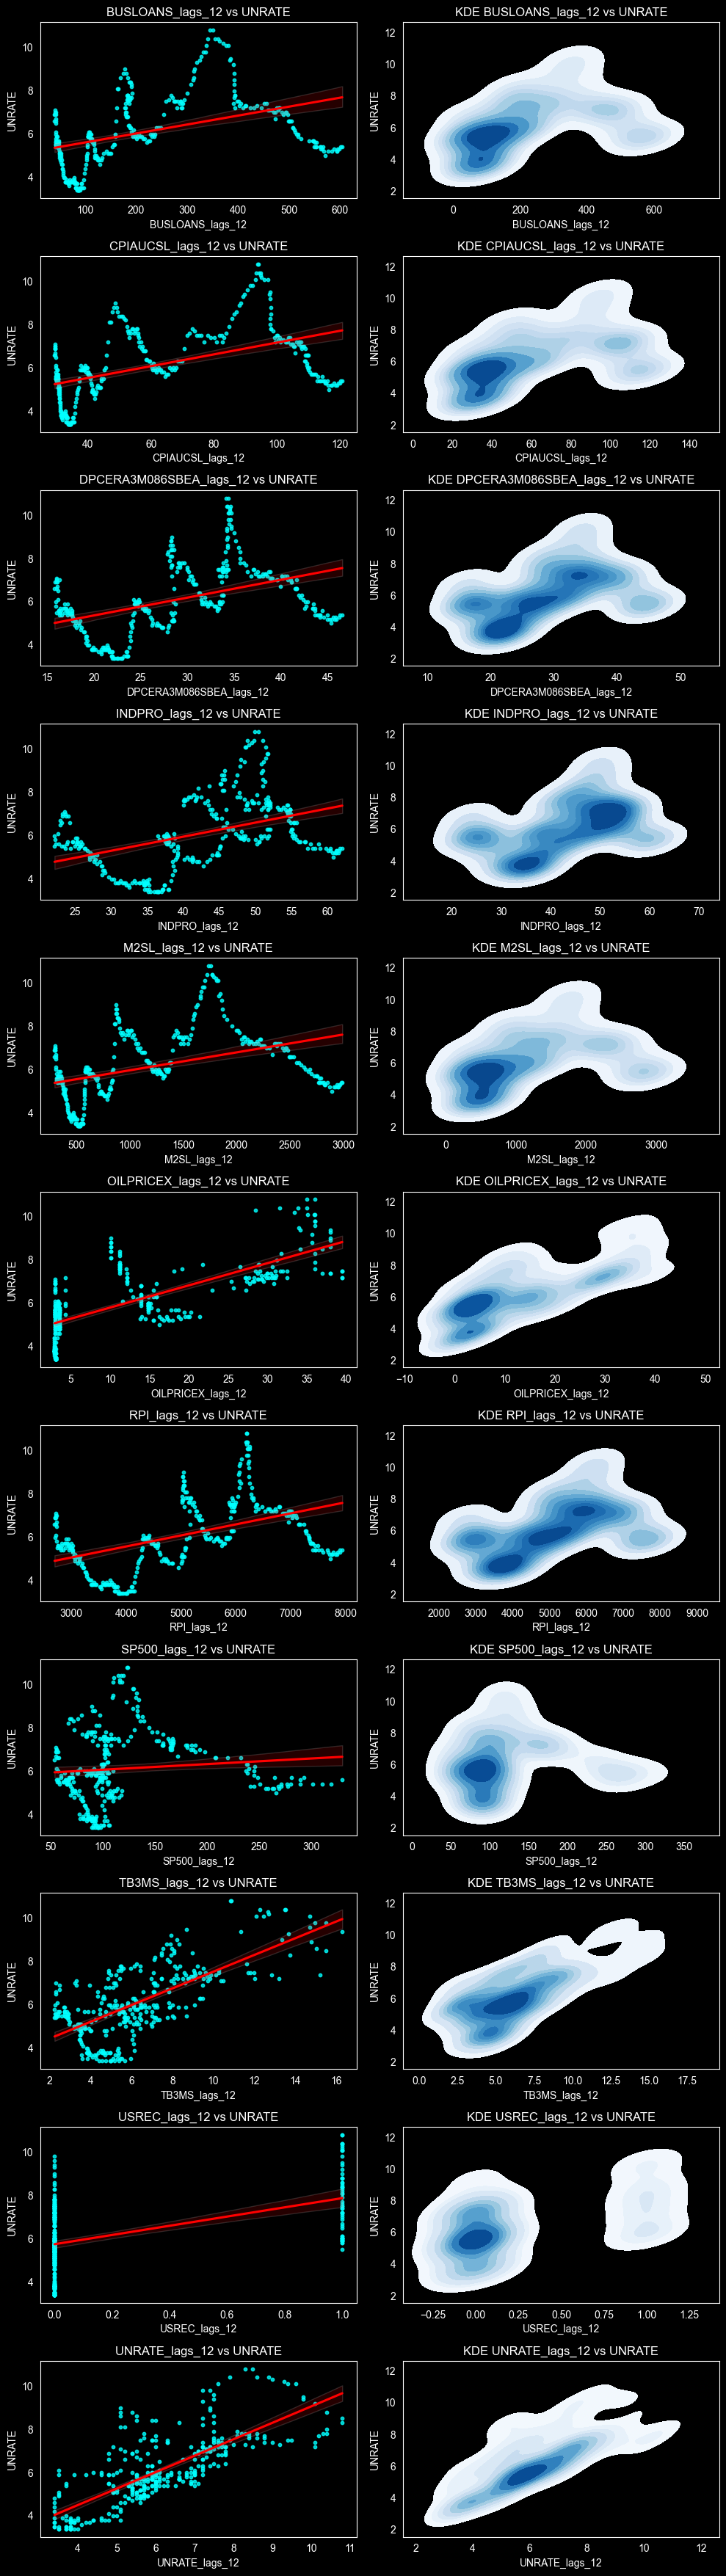

In [12]:
plot_reg_and_kde_grid(df_train_lags, y="UNRATE")

**Règles de lecture dans le cadre de l'hypothèse de linéarité**
- A gauche, on le scatter plot de chaque variable avec le taux de chômage. Ce qui est intéressant ici c'est 
    - Pente rouge : droite de régression linéaire entre les deux variables
    - La pente est équipée d'intervalle de confiance
    - Pente forte + nuage serré → relation claire
    - Pente faible + nuage dispersé → relation faible
    - Beaucoup de dispersion → incertitude élevée
- A droite, il y a l'estimation de la densité des points des deux variables pour mesurer le zone de concentration des observations :
  - Zones foncées -> beaucoup d'observations
  - Forme circulaire
  - allongé en diagonale → lien réel
  - rond → lien faible / nul
  - plusieurs “blobs” → régimes différents

## Interprétation

- On s'aperçoit que les variables pro-cycliques de l'économie sont corrélées au taux de chômage : 
    - INDPRO : Une augmentation du taux de croissance de la production industrielle signifierait une baisse du taux de croissance du chômage et vice-versa ;   
    - RPI : La direction du changement de revenu anticipe celle du chômage ; 
    - La consommation des ménages (DPCE) va aussi dans ce sens du revenu.
- La performance du système financier aussi, à travers l'indice boursier SP500, nous permet d'anticiper le chômage à venir. 
- Pour les autres variables, on constate une densité circulaire. Ce qui signifie qu'il existe une faible dépendance linéaire.
- Nous allons quantifier la corrélation pour confirmer notre analyse.

## Quantifier la corrélation

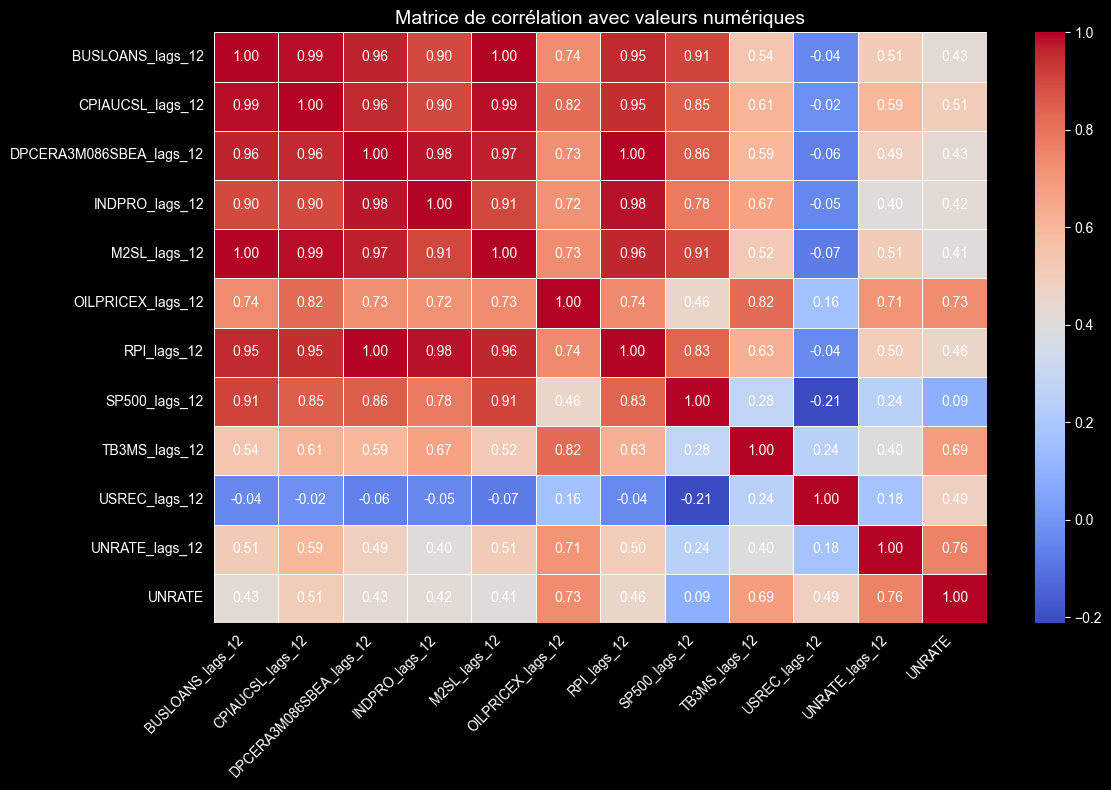

In [13]:
plot_corr_heatmap(df_train_lags)

La quantification de la corrélation nous sert à confirmer notre étude ci-dessus. Voici donc les variables qui permettent d'anticiper la croissance de chômage dans 12 mois :
- SP500 (0.41) ; 
- DP (-0.39) ;
- RPI (-0.34) ; 
- INDPRO (0.29) ; 

Une autre relation s'émerge ici, celle du taux de chômage et de la récession (USREC). D'ailleurs, c'est la relation la plus forte. Essayons de traduire la relation à partir d'un graphique.

In [14]:
df_train_lags.columns

Index(['BUSLOANS_lags_12', 'CPIAUCSL_lags_12', 'DPCERA3M086SBEA_lags_12',
       'INDPRO_lags_12', 'M2SL_lags_12', 'OILPRICEX_lags_12', 'RPI_lags_12',
       'SP500_lags_12', 'TB3MS_lags_12', 'USREC_lags_12', 'UNRATE_lags_12',
       'UNRATE'],
      dtype='object')